In [1]:
import pandas as pd
from ast import literal_eval

datainpout = "/home/y-guo/NLP2026/Output/diversity_cache_lex_syn_sem.csv"
diversity_df = pd.read_csv(datainpout)

In [2]:
paras2diversity = {}
for data in diversity_df.to_dict(orient="records"):
    sorted_paras = tuple(literal_eval(data['paraphrases']))
    paras2diversity[sorted_paras] = {
        "lexical_diversity": data["lexical_diversity"],
        "syntactic_diversity": data["syntactic_diversity"],
        "semantic_diversity": data["semantic_diversity"],
    }

In [ ]:
import pandas as pd

def calculate_diversity_level(model_name, num_shots):
    path = f"/home/y-guo/NLP2026/Output/{model_name}/myriadlama/myriadlama.{model_name}.parallel.avg.{num_shots}shots.5samples.5paras.feather"
    df = pd.read_feather(path)
    for idx, row in df.iterrows():
        this_paras = tuple(sorted(row["paraphrases"].tolist()))
        assert this_paras in paras2diversity, f"Missing paraphrases: {this_paras}"
        if this_paras in paras2diversity:
            df.at[idx, 'lexical_diversity'] = paras2diversity[this_paras]['lexical_diversity']
            df.at[idx, 'syntactic_diversity'] = paras2diversity[this_paras]['syntactic_diversity']
            df.at[idx, 'semantic_diversity'] = paras2diversity[this_paras]['semantic_diversity']
    diversity_levels = {
        "lexical_diversity": [[] for _ in range(5)],
        "syntactic_diversity": [[] for _ in range(5)],
        "semantic_diversity": [[] for _ in range(5)],
    }
    for uuid in df['uuid'].unique():
        sdf = df[df['uuid'] == uuid]
        lexical_sorted_df = sdf.sort_values(by="lexical_diversity")
        syntactic_sorted_df = sdf.sort_values(by="syntactic_diversity")
        semantic_sorted_df = sdf.sort_values(by="semantic_diversity")
        for i in range(5):
            diversity_levels["lexical_diversity"][i].append(lexical_sorted_df.iloc[i])
            diversity_levels["syntactic_diversity"][i].append(syntactic_sorted_df.iloc[i])
            diversity_levels["semantic_diversity"][i].append(semantic_sorted_df.iloc[i])

    for i in range(5):
        diversity_levels["lexical_diversity"][i] = pd.DataFrame(diversity_levels["lexical_diversity"][i])
        diversity_levels["syntactic_diversity"][i] = pd.DataFrame(diversity_levels["syntactic_diversity"][i])
        diversity_levels["semantic_diversity"][i] = pd.DataFrame(diversity_levels["semantic_diversity"][i])
    return diversity_levels
    

In [60]:
from notebooks._utils import calculate_accuracy

model2accuracy = {}

MODEL_NAMES = {
    "qwen3_0.6b": "Qwen3-0.6b",
    "qwen3_1.7b": "Qwen3-1.7b",
    "qwen3_4b": "Qwen3-4b",
    "qwen3_8b": "Qwen3-8b"
}
for model_name in ["qwen3_0.6b", "qwen3_1.7b", "qwen3_4b", "qwen3_8b"]:
    model2accuracy[MODEL_NAMES[model_name]] = {
        "lexical_diversity": [],
        "syntactic_diversity": [],
        "semantic_diversity": [],
    }
    diversity_levels = calculate_diversity_level(model_name, 5)
    for i in range(5):
        for diversity_type in ["lexical_diversity", "syntactic_diversity", "semantic_diversity"]:
            acc = calculate_accuracy(
                diversity_levels[diversity_type][i], is_multichoice=False,
                birdirect=True, use_generation=True, by_probs=False,
                label="Ensembled accuracy", verbose=False)
            model2accuracy[MODEL_NAMES[model_name]][diversity_type].append(acc)
        

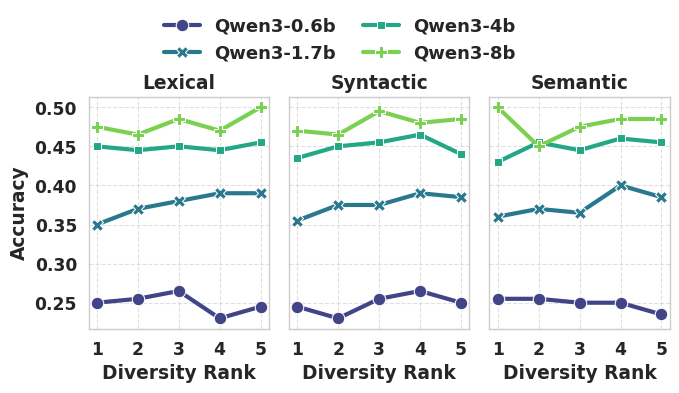

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

data_list = []
for model, metrics in model2accuracy.items():
    for metric_name, values in metrics.items():
        for step, value in enumerate(values):
            data_list.append({
                'Model': model,
                # We keep the full name here for filtering, but clean it in the title later
                'Metric': metric_name.replace('_', ' ').title(),
                'Step': step + 1,
                'Score': value
            })
df = pd.DataFrame(data_list)

# 2. Setup Style (Compact)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

# 3. Compact Figure Size
fig, axes = plt.subplots(1, 3, figsize=(7, 3.5), sharey=True)
plt.subplots_adjust(wspace=0.1)

palette = sns.color_palette("viridis", n_colors=len(df['Model'].unique()))
unique_metrics = df['Metric'].unique()

for i, metric in enumerate(unique_metrics):
    ax = axes[i]
    metric_data = df[df['Metric'] == metric]
    
    sns.lineplot(
        data=metric_data,
        x='Step',
        y='Score',
        hue='Model',
        style='Model',
        markers=True,
        dashes=False,
        palette=palette,
        linewidth=3,
        markersize=9,
        ax=ax
    )
    
    # Clean Title: Remove " Diversity"
    clean_title = metric.replace(" Diversity", "")
    ax.set_title(clean_title)
    
    # Set X-Label to "Diversity Rank"
    ax.set_xlabel("Diversity Rank")
    ax.set_xticks([1, 2, 3, 4, 5])
    
    if i == 0:
        ax.set_ylabel("Accuracy")
    else:
        ax.set_ylabel("") # Hide y-label for inner plots
        
    ax.grid(True, linestyle='--', alpha=0.6)
    if ax.get_legend():
        ax.get_legend().remove()

# 4. Legend with ncol=2
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), 
           ncol=2, frameon=False, fontsize=13, columnspacing=1.5)

plt.tight_layout()
plt.savefig("diversity_accuracy_comparision.pdf", format='pdf', bbox_inches='tight')
plt.show()